# Training Curves from `training_logs_aws.json`

This notebook loads `training_logs_aws.json` and plots:
- MSE: train vs validation
- MAE: train vs validation (when train MAE exists in logs)


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

LOG_PATH = Path("training_logs_aws.json")
if not LOG_PATH.exists():
    raise FileNotFoundError(f"Missing log file: {LOG_PATH.resolve()}")

raw_text = LOG_PATH.read_text().strip()
rows = []

# Support both JSONL (one object per line) and regular JSON.
try:
    payload = json.loads(raw_text)
    if isinstance(payload, list):
        rows = payload
    elif isinstance(payload, dict):
        rows = [payload]
except json.JSONDecodeError:
    for line in raw_text.splitlines():
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No rows parsed from training_logs_aws.json")

if "step" not in df.columns:
    df["step"] = range(1, len(df) + 1)

df = df.sort_values("step").reset_index(drop=True)

# Normalize expected train metric column names.
if "train_mse_epoch" not in df.columns and "train_loss_epoch" in df.columns:
    df["train_mse_epoch"] = df["train_loss_epoch"]

if "train_mae" not in df.columns and "train_mae_epoch" in df.columns:
    df["train_mae"] = df["train_mae_epoch"]

# Detect boundaries between epochs (first step of each new epoch).
epoch_boundaries = []
if "epoch" in df.columns:
    epoch_changes = df["epoch"].ne(df["epoch"].shift()) & (df.index > 0)
    epoch_boundaries = (
        df.loc[epoch_changes, "step"]
        .dropna()
        .astype(float)
        .astype(int)
        .tolist()
    )

print(f"rows: {len(df)}")
print("columns:", sorted(df.columns.tolist()))
print(f"epoch boundaries: {len(epoch_boundaries)}")
df.head(3)


rows: 91
columns: ['epoch', 'eval_batches', 'eval_max_batches', 'eval_scope', 'step', 'test_mae', 'test_mae_hi', 'test_mae_lo', 'test_mse', 'test_mse_hi', 'test_mse_lo', 'train_loss_epoch', 'train_mse_epoch', 'val_mae', 'val_mae_hi', 'val_mae_lo', 'val_mse', 'val_mse_hi', 'val_mse_lo']
epoch boundaries: 1


,epoch,step,eval_scope,eval_batches,eval_max_batches,train_loss_epoch,train_mse_epoch,val_mse,val_mse_lo,val_mse_hi,val_mae,val_mae_lo,val_mae_hi,test_mse,test_mse_lo,test_mse_hi,test_mae,test_mae_lo,test_mae_hi
0,0,200,step,64,64,11.801795,11.801795,13.031321,11.243883,15.408059,1.114843,1.071558,1.168470,NaN,NaN,NaN,NaN,NaN,NaN
1,0,400,step,64,64,11.553817,11.553817,12.272725,10.521710,14.666206,1.083237,1.040361,1.135224,NaN,NaN,NaN,NaN,NaN,NaN
2,0,600,step,64,64,11.011599,11.011599,10.829725,9.151524,13.240228,1.020305,0.978452,1.068394,NaN,NaN,NaN,NaN,NaN,NaN


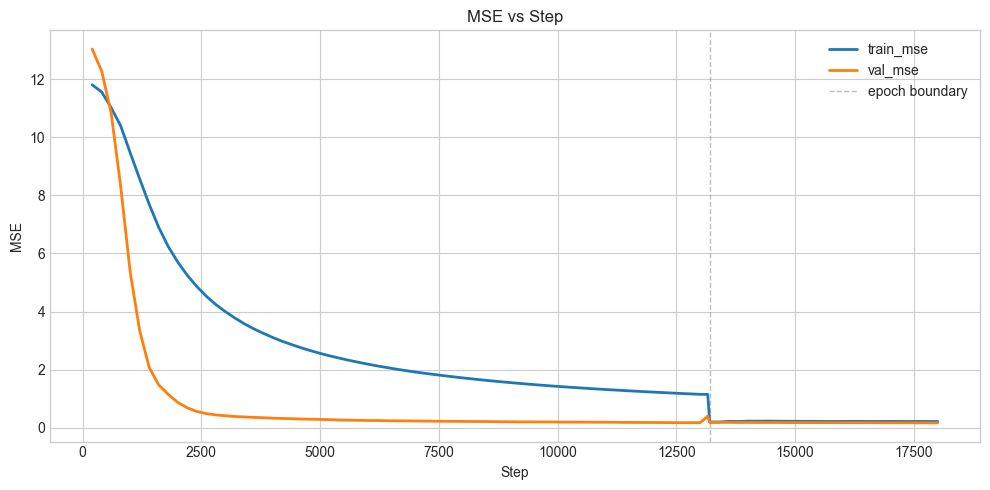

In [2]:
# MSE curves
fig, ax = plt.subplots(figsize=(10, 5))

if "train_mse_epoch" in df.columns:
    ax.plot(df["step"], df["train_mse_epoch"], label="train_mse", linewidth=2)

if "val_mse" in df.columns:
    ax.plot(df["step"], df["val_mse"], label="val_mse", linewidth=2)

for i, boundary_step in enumerate(epoch_boundaries):
    ax.axvline(
        boundary_step,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="epoch boundary" if i == 0 else None,
    )

ax.set_title("MSE vs Step")
ax.set_xlabel("Step")
ax.set_ylabel("MSE")
ax.legend()
plt.tight_layout()
plt.show()


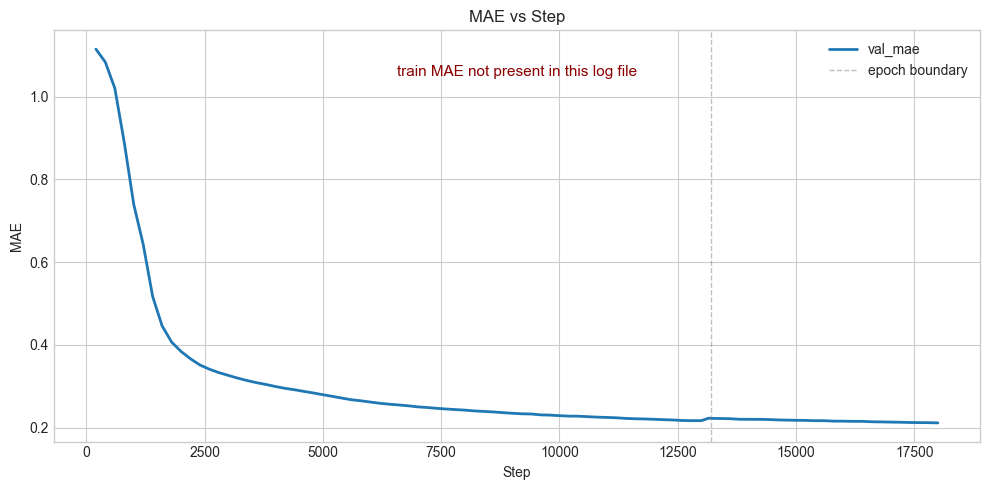

In [3]:
# MAE curves
fig, ax = plt.subplots(figsize=(10, 5))

train_mae_col = None
for col in ["train_mae", "train_mae_epoch"]:
    if col in df.columns:
        train_mae_col = col
        break

if train_mae_col is not None:
    ax.plot(df["step"], df[train_mae_col], label="train_mae", linewidth=2)
else:
    ax.text(
        0.5,
        0.9,
        "train MAE not present in this log file",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color="darkred",
    )

if "val_mae" in df.columns:
    ax.plot(df["step"], df["val_mae"], label="val_mae", linewidth=2)

for i, boundary_step in enumerate(epoch_boundaries):
    ax.axvline(
        boundary_step,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="epoch boundary" if i == 0 else None,
    )

ax.set_title("MAE vs Step")
ax.set_xlabel("Step")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()
